In [28]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# Load the NAV history data
nav_df = pd.read_csv('/content/02_nav_history.csv')

# Display the first few rows and information about the DataFrame
print("NAV History DataFrame Head:")
display(nav_df.head())
print("\nNAV History DataFrame Info:")
nav_df.info()

NAV History DataFrame Head:


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692



NAV History DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [2]:
# Convert 'date' column to datetime objects
nav_df['date'] = pd.to_datetime(nav_df['date'])

# Load the fund master data to get scheme names
fund_master_df = pd.read_csv('/content/01_fund_master.csv')

# Merge nav_df with fund_master_df to get scheme names
nav_df = pd.merge(nav_df, fund_master_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

# Identify the top 40 schemes based on the unique amfi_code in nav_df
top_40_schemes = nav_df['amfi_code'].value_counts().nlargest(40).index

# Filter nav_df for these top 40 schemes
nav_df_filtered = nav_df[nav_df['amfi_code'].isin(top_40_schemes)].copy()

# Display info for the filtered DataFrame to confirm data types and missing values
print("\nNAV History Filtered DataFrame Info:")
nav_df_filtered.info()

print("\nNAV History Filtered DataFrame Head:")
display(nav_df_filtered.head())


NAV History Filtered DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   amfi_code    46000 non-null  int64         
 1   date         46000 non-null  datetime64[ns]
 2   nav          46000 non-null  float64       
 3   scheme_name  46000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 1.4+ MB

NAV History Filtered DataFrame Head:


,amfi_code,date,nav,scheme_name
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth


In [3]:
# Filter data for the requested years (2022-2026)
nav_df_filtered_years = nav_df_filtered[(nav_df_filtered['date'].dt.year >= 2022) & (nav_df_filtered['date'].dt.year <= 2026)]

# Create a Plotly figure
fig = go.Figure()

# Add a trace for each scheme
for amfi_code, group in nav_df_filtered_years.groupby('amfi_code'):
    scheme_name = group['scheme_name'].iloc[0] # Get the scheme name
    fig.add_trace(go.Scatter(
        x=group['date'],
        y=group['nav'],
        mode='lines',
        name=f'{scheme_name} ({amfi_code})',
        hovertemplate='<b>Scheme:</b> %{full_name}<br><b>Date:</b> %{x|%Y-%m-%d}<br><b>NAV:</b> %{y:.4f}<extra></extra>'
    ))

# Define the periods for bull run and market correction
bull_run_start = '2023-01-01'
bull_run_end = '2023-12-31'
market_correction_start = '2024-03-01' # Placeholder for a plausible market correction period
market_correction_end = '2024-06-30' # Placeholder for a plausible market correction period

# Add shapes for bull run and market correction
fig.add_vrect(x0=bull_run_start, x1=bull_run_end,
              fillcolor="rgba(0,255,0,0.1)",
              layer="below", line_width=0,
              annotation_text="2023 Bull Run",
              annotation_position="top left")

fig.add_vrect(x0=market_correction_start, x1=market_correction_end,
              fillcolor="rgba(255,0,0,0.1)",
              layer="below", line_width=0,
              annotation_text="2024 Market Correction",
              annotation_position="top right")

# Update layout for title and axis labels
fig.update_layout(
    title_text='Daily NAV Trend for Top 40 Schemes (2022-2026)',
    xaxis_title='Date',
    yaxis_title='Net Asset Value (NAV)',
    hovermode='x unified',
    height=700,
    legend_title_text='Scheme',
    xaxis_rangeselector_buttons=list([
        dict(count=1, label="1m", step="month", stepmode="backward"),
        dict(count=6, label="6m", step="month", stepmode="backward"),
        dict(count=1, label="YTD", step="year", stepmode="todate"),
        dict(count=1, label="1y", step="year", stepmode="backward"),
        dict(step="all")
    ])
)

fig.update_xaxes(rangeslider_visible=True)
fig.show()

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the AUM by fund house data
aum_df = pd.read_csv('/content/03_aum_by_fund_house.csv')

# Display the first few rows and information about the DataFrame
print("AUM DataFrame Head:")
display(aum_df.head())
print("\nAUM DataFrame Info:")
aum_df.info()

AUM DataFrame Head:


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168



AUM DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     object 
 1   fund_house      90 non-null     object 
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3.6+ KB


/tmp/ipykernel_1327/1107784782.py:16: UserWarning:

The palette list has more values (10) than needed (4), which may not be intended.



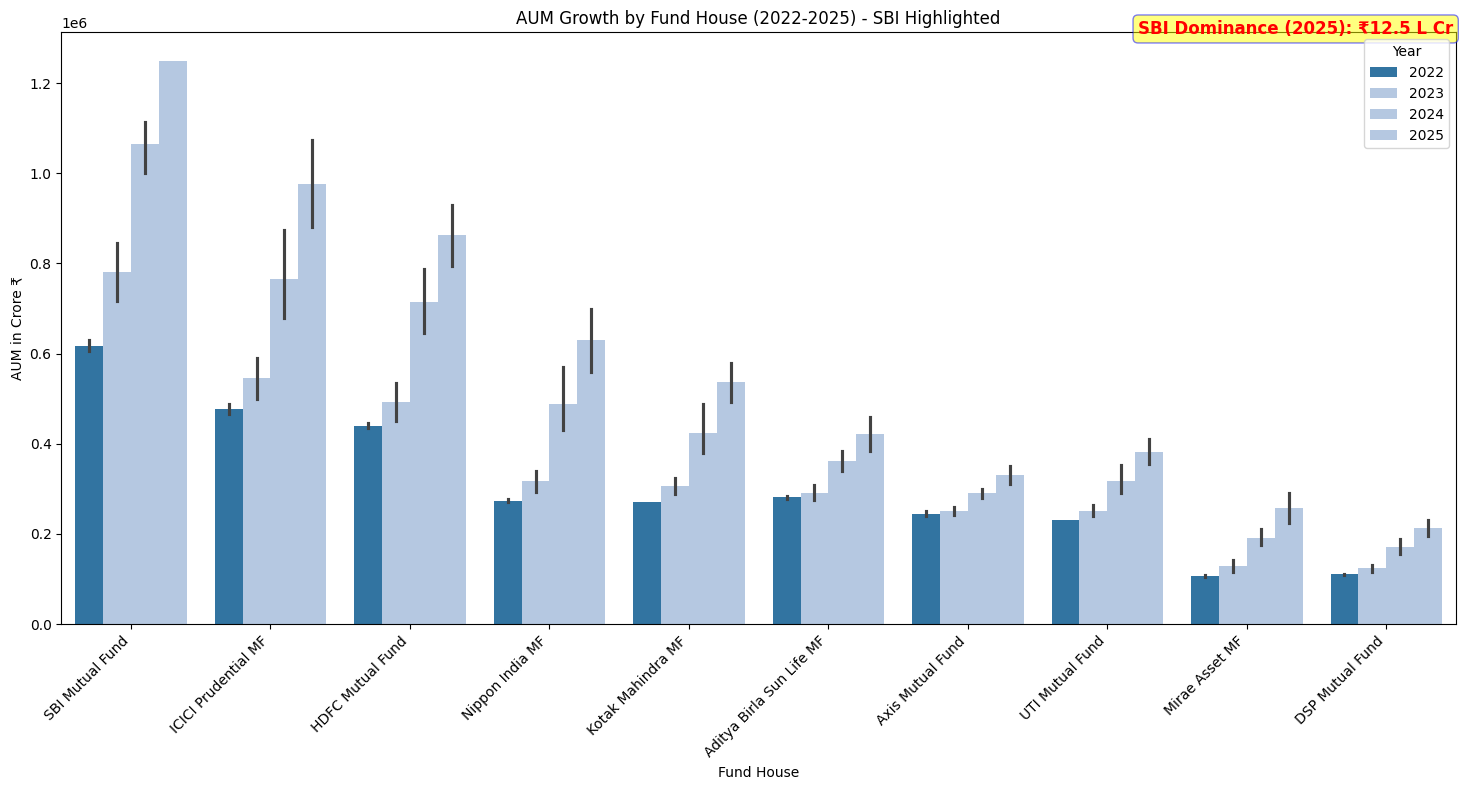

In [6]:
# Convert 'date' column to datetime objects first
aum_df['date'] = pd.to_datetime(aum_df['date'])

# Extract 'year' from the 'date' column
aum_df['year'] = aum_df['date'].dt.year.astype(str)

# Filter for years 2022-2025
aum_df_filtered = aum_df[aum_df['year'].isin(['2022', '2023', '2024', '2025'])].copy()

# Define a color palette, highlighting SBI
unique_fund_houses = aum_df_filtered['fund_house'].unique()
palette = ['#1f77b4' if fund == 'SBI Mutual Fund' else '#aec7e8' for fund in unique_fund_houses]

# Create the grouped bar chart
plt.figure(figsize=(15, 8))
sns.barplot(data=aum_df_filtered, x='fund_house', y='aum_crore', hue='year', palette=palette)

# Highlight SBI's dominance for 2025
sbi_aum_2025_cr = aum_df_filtered[(aum_df_filtered['fund_house'] == 'SBI Mutual Fund') & (aum_df_filtered['year'] == '2025')]['aum_crore'].max()
sbi_aum_2025_lakh_cr = aum_df_filtered[(aum_df_filtered['fund_house'] == 'SBI Mutual Fund') & (aum_df_filtered['year'] == '2025')]['aum_lakh_crore'].max()

# Find the x-coordinate for SBI Mutual Fund on the plot
# This assumes 'SBI Mutual Fund' is present in the x-axis categories
fund_house_order = aum_df_filtered.sort_values(by=['year', 'fund_house'])['fund_house'].unique()
sbi_x_pos = list(fund_house_order).index('SBI Mutual Fund')

plt.text(sbi_x_pos + 0.35, sbi_aum_2025_cr + 50000, f'SBI Dominance (2025): ₹{sbi_aum_2025_lakh_cr:,.1f} L Cr', # Adjust x-pos and y-pos as needed
         ha='center', va='bottom', color='red', weight='bold', fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=1, alpha=0.5))

plt.title('AUM Growth by Fund House (2022-2025) - SBI Highlighted')
plt.xlabel('Fund House')
plt.ylabel('AUM in Crore ₹')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

In [7]:
# Load the monthly SIP inflows data
sip_df = pd.read_csv('/content/04_monthly_sip_inflows.csv')

# Display the first few rows and information about the DataFrame
print("SIP Inflows DataFrame Head:")
display(sip_df.head())
print("\nSIP Inflows DataFrame Info:")
sip_df.info()

SIP Inflows DataFrame Head:


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN



SIP Inflows DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     object 
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 2.4+ KB


In [9]:
# Convert 'month' to datetime objects for proper time-series plotting
sip_df['month'] = pd.to_datetime(sip_df['month'])

# Filter for the requested period: Jan 2022 to Dec 2025
sip_df_filtered = sip_df[
    (sip_df['month'] >= '2022-01-01') &
    (sip_df['month'] <= '2025-12-31')
].copy()

# Create a Plotly figure for SIP inflow time-series
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=sip_df_filtered['month'],
    y=sip_df_filtered['sip_inflow_crore'],
    mode='lines+markers',
    name='Monthly SIP Inflow',
    hovertemplate='<b>Date:</b> %{x|%b %Y}<br><b>SIP Inflow:</b> ₹%{y:,.0f} Cr<extra></extra>'
))

# Annotate the all-time high of ₹31,002 Cr in Dec 2025
# Find the row corresponding to Dec 2025 SIP inflow (31002 Cr)
# Assuming '2025-12-01' will correctly find the December 2025 entry if formatted as monthly data
max_sip_row = sip_df_filtered[
    (sip_df_filtered['month'].dt.year == 2025) &
    (sip_df_filtered['month'].dt.month == 12)
].iloc[0]

fig.add_annotation(
    x=max_sip_row['month'],
    y=max_sip_row['sip_inflow_crore'],
    text=f'All-time High: ₹{max_sip_row["sip_inflow_crore"]:,.0f} Cr (Dec 2025)',
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-40,
    font=dict(size=12, color="red"),
    bgcolor="rgba(255, 255, 0, 0.5)",
    bordercolor="red",
    borderwidth=1,
    borderpad=4
)

# Update layout
fig.update_layout(
    title_text='Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)',
    xaxis_title='Date',
    yaxis_title='SIP Inflow (₹ Crore)',
    hovermode='x unified',
    height=600,
    xaxis_rangeselector_buttons=list([
        dict(count=1, label="1m", step="month", stepmode="backward"),
        dict(count=6, label="6m", step="month", stepmode="backward"),
        dict(count=1, label="YTD", step="year", stepmode="todate"),
        dict(count=1, label="1y", step="year", stepmode="backward"),
        dict(step="all")
    ])
)

fig.update_xaxes(rangeslider_visible=True)
fig.show()

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the category inflows data
category_inflows_df = pd.read_csv('/content/05_category_inflows.csv')

# Display the first few rows and information about the DataFrame
print("Category Inflows DataFrame Head:")
display(category_inflows_df.head())
print("\nCategory Inflows DataFrame Info:")
category_inflows_df.info()

Category Inflows DataFrame Head:


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0



Category Inflows DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    object 
 1   category          144 non-null    object 
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.5+ KB


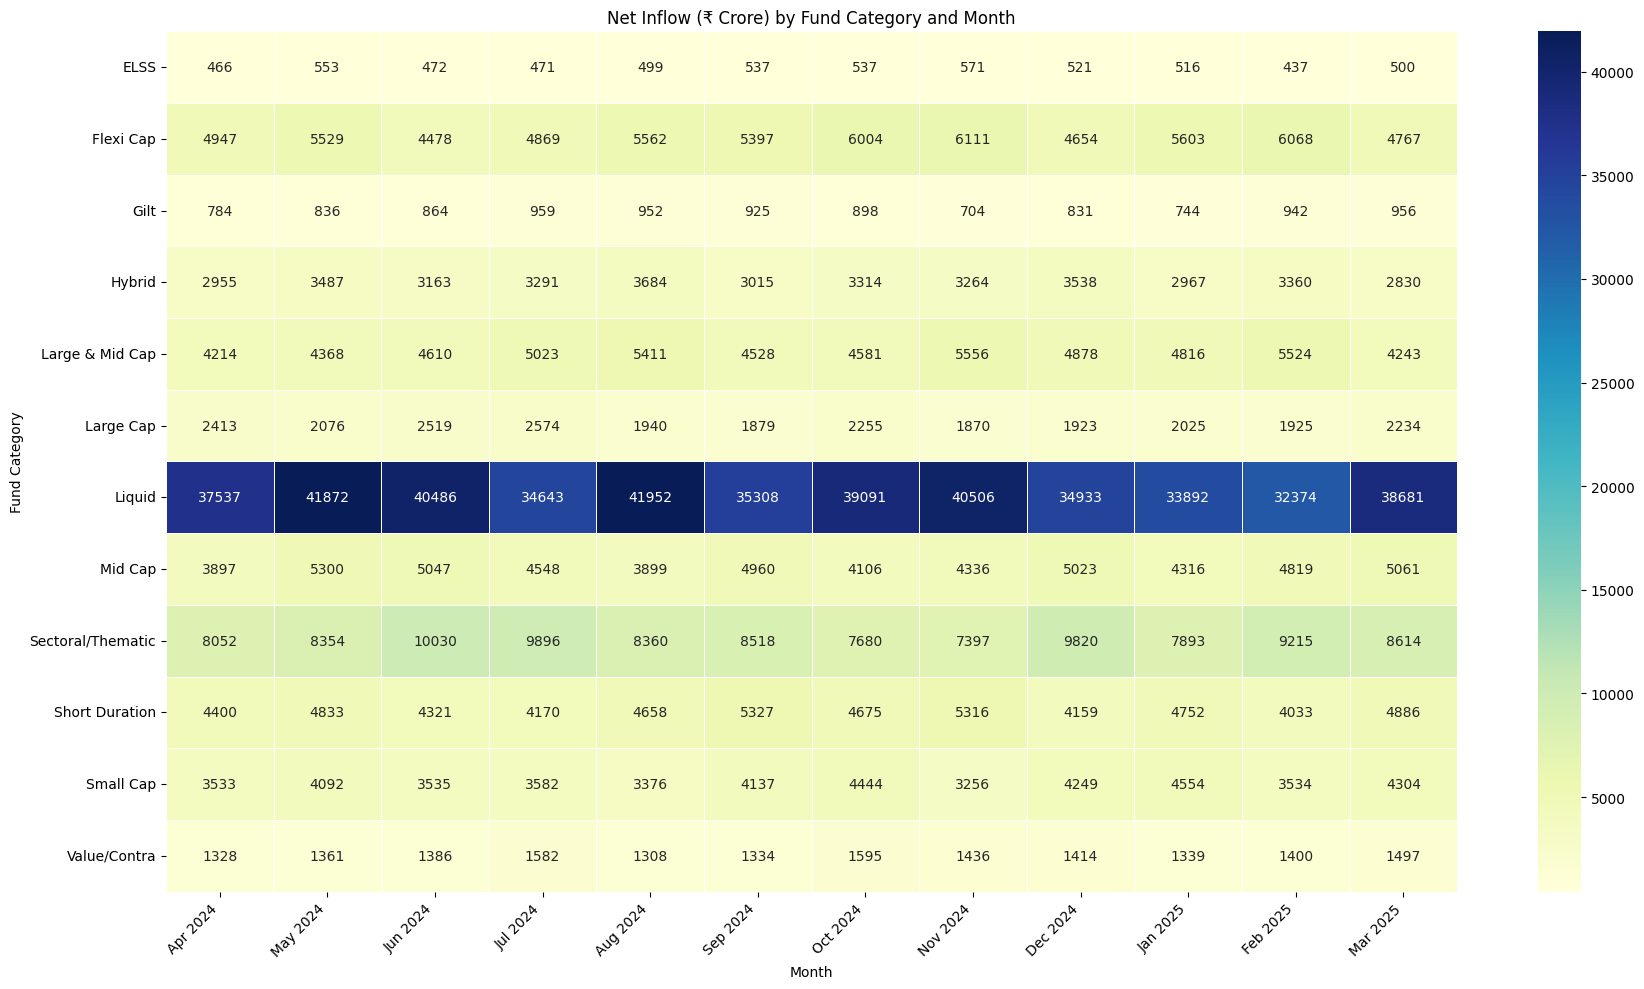

In [12]:
# Convert 'month' to datetime objects and extract month name and year
category_inflows_df['month'] = pd.to_datetime(category_inflows_df['month'])
category_inflows_df['year_month'] = category_inflows_df['month'].dt.strftime('%Y-%m')
category_inflows_df['month_name'] = category_inflows_df['month'].dt.strftime('%b %Y')

# Create a pivot table for the heatmap
# Months on X-axis, fund categories on Y-axis, net inflow as color intensity
heatmap_data = category_inflows_df.pivot_table(index='category',
                                                 columns='month_name',
                                                 values='net_inflow_crore')

# Reorder columns to ensure chronological order of months
# Get unique month_name in chronological order
ordered_months = category_inflows_df.sort_values('month')['month_name'].unique()
heatmap_data = heatmap_data[ordered_months]

# Create the heatmap
plt.figure(figsize=(18, 10))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5, linecolor='white')
plt.title('Net Inflow (₹ Crore) by Fund Category and Month')
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
# Load the investor transactions data
investor_df = pd.read_csv('/content/08_investor_transactions.csv')

# Display the first few rows and information about the DataFrame
print("Investor Transactions DataFrame Head:")
display(investor_df.head())
print("\nInvestor Transactions DataFrame Info:")
investor_df.info()

Investor Transactions DataFrame Head:


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending



Investor Transactions DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


In [14]:
# Calculate age group distribution
age_group_distribution = investor_df['age_group'].value_counts().reset_index()
age_group_distribution.columns = ['age_group', 'count']

# Create a pie chart for age group distribution
fig = go.Figure(data=[go.Pie(labels=age_group_distribution['age_group'],
                             values=age_group_distribution['count'],
                             hole=.3)])
fig.update_layout(
    title_text='Investor Age Group Distribution',
    annotations=[dict(text='Age Groups', x=0.5, y=0.5, font_size=20, showarrow=False)]
)
fig.show()

In [15]:
# Create a box plot for SIP amount by age group
# Filter for SIP transactions only
sip_transactions_df = investor_df[investor_df['transaction_type'] == 'SIP']

# Order age groups for better visualization
age_group_order = ['18-25', '26-35', '36-45', '46-55', '56+']

fig = px.box(
    sip_transactions_df,
    x='age_group',
    y='amount_inr',
    category_orders={'age_group': age_group_order},
    title='SIP Amount Distribution by Age Group',
    labels={'age_group': 'Age Group', 'amount_inr': 'SIP Amount (INR)'},
    color='age_group' # Color by age group
)

fig.update_layout(xaxis_title='Age Group', yaxis_title='SIP Amount (INR)')
fig.show()

NameError: name 'px' is not defined

In [16]:
# Calculate gender split
gender_split = investor_df['gender'].value_counts().reset_index()
gender_split.columns = ['gender', 'count']

# Create a pie chart for gender split
fig = go.Figure(data=[go.Pie(labels=gender_split['gender'],
                             values=gender_split['count'],
                             hole=.3)])
fig.update_layout(
    title_text='Investor Gender Split',
    annotations=[dict(text='Gender', x=0.5, y=0.5, font_size=20, showarrow=False)]
)
fig.show()

In [18]:
# Geographic distribution: SIP amount by state (horizontal bar chart)
# Filter for SIP transactions
sip_by_state = investor_df[investor_df['transaction_type'] == 'SIP'].groupby('state')['amount_inr'].sum().reset_index()
sip_by_state = sip_by_state.sort_values('amount_inr', ascending=True)

fig = px.bar(
    sip_by_state,
    x='amount_inr',
    y='state',
    orientation='h',
    title='Total SIP Amount by State',
    labels={'amount_inr': 'Total SIP Amount (INR)', 'state': 'State'},
    height=700
)
fig.update_layout(yaxis_title='State', xaxis_title='Total SIP Amount (INR)')
fig.show()

In [19]:
# Geographic distribution: T30 vs B30 city tier pie chart
city_tier_distribution = investor_df['city_tier'].value_counts().reset_index()
city_tier_distribution.columns = ['city_tier', 'count']

fig = go.Figure(data=[go.Pie(labels=city_tier_distribution['city_tier'],
                             values=city_tier_distribution['count'],
                             hole=.3)])
fig.update_layout(
    title_text='Investor Distribution by City Tier (T30 vs B30)',
    annotations=[dict(text='City Tiers', x=0.5, y=0.5, font_size=20, showarrow=False)]
)
fig.show()

In [20]:
# Folio count growth (line chart)
# Load the industry folio count data
folio_df = pd.read_csv('/content/06_industry_folio_count.csv')

# Display the first few rows and information about the DataFrame
print("Folio Count DataFrame Head:")
display(folio_df.head())
print("\nFolio Count DataFrame Info:")
folio_df.info()


Folio Count DataFrame Head:


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48



Folio Count DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     object 
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.1+ KB


In [22]:
# Convert 'month' column to datetime objects
folio_df['month'] = pd.to_datetime(folio_df['month'])

# Filter for the relevant period (Jan 2022 to Dec 2025)
folio_df_filtered = folio_df[(folio_df['month'] >= '2022-01-01') & (folio_df['month'] <= '2025-12-31')].copy()

# Create a Plotly line chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=folio_df_filtered['month'],
    y=folio_df_filtered['total_folios_crore'],
    mode='lines+markers',
    name='Total Folio Count',
    hovertemplate='<b>Date:</b> %{x|%b %Y}<br><b>Folio Count:</b> %{y:.2f} Cr<extra></extra>'
))

# Mark key milestones: 13.26 Cr (Jan 2022) and 26.12 Cr (Dec 2025)
# Find data points for annotations
jan_2022_folio = folio_df_filtered[folio_df_filtered['month'] == '2022-01-01'].iloc[0]
dec_2025_folio = folio_df_filtered[folio_df_filtered['month'] == '2025-12-01'].iloc[0]

fig.add_annotation(
    x=jan_2022_folio['month'],
    y=jan_2022_folio['total_folios_crore'],
    text=f"Jan 2022: {jan_2022_folio['total_folios_crore']:.2f} Cr",
    showarrow=True, arrowhead=2, ax=0, ay=-40,
    font=dict(size=12, color="blue"),
    bgcolor="rgba(255, 255, 0, 0.5)", bordercolor="blue", borderwidth=1, borderpad=4
)

fig.add_annotation(
    x=dec_2025_folio['month'],
    y=dec_2025_folio['total_folios_crore'],
    text=f"Dec 2025: {dec_2025_folio['total_folios_crore']:.2f} Cr",
    showarrow=True, arrowhead=2, ax=0, ay=-40,
    font=dict(size=12, color="green"),
    bgcolor="rgba(255, 255, 0, 0.5)", bordercolor="green", borderwidth=1, borderpad=4
)

# Update layout
fig.update_layout(
    title_text='Industry Folio Count Growth (Jan 2022 - Dec 2025)',
    xaxis_title='Date',
    yaxis_title='Total Folio Count (Crore)',
    hovermode='x unified',
    height=600,
    xaxis_rangeselector_buttons=list([
        dict(count=1, label="1m", step="month", stepmode="backward"),
        dict(count=6, label="6m", step="month", stepmode="backward"),
        dict(count=1, label="YTD", step="year", stepmode="todate"),
        dict(count=1, label="1y", step="year", stepmode="backward"),
        dict(step="all")
    ])
)

fig.update_xaxes(rangeslider_visible=True)
fig.show()

In [23]:
# NAV return correlation matrix

# Select 10 funds from the filtered NAV data for correlation analysis
selected_amfi_codes = nav_df_filtered['amfi_code'].unique()[:10]
nav_10_funds = nav_df_filtered[nav_df_filtered['amfi_code'].isin(selected_amfi_codes)].copy()

# Calculate daily returns
nav_10_funds['daily_return'] = nav_10_funds.groupby('amfi_code')['nav'].pct_change()

# Pivot the table to have dates as index, scheme_name as columns, and daily_return as values
returns_pivot = nav_10_funds.pivot_table(index='date', columns='scheme_name', values='daily_return')

# Drop NaN values that resulted from pct_change (first return for each fund) and any other missing data
returns_pivot = returns_pivot.dropna()

# Compute the correlation matrix
correlation_matrix = returns_pivot.corr()

# Display the correlation matrix head
print("Correlation Matrix Head:")
display(correlation_matrix.head())


Correlation Matrix Head:


scheme_name,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
scheme_name,,,,,,,,,,
HDFC Mid-Cap Opportunities Fund - Direct - Growth,1.000000,-0.011916,-0.025505,0.027394,-0.016089,-0.052299,0.030454,-0.016315,0.041927,0.018443
HDFC Mid-Cap Opportunities Fund - Regular - Growth,-0.011916,1.000000,0.002150,-0.025137,-0.000006,-0.027471,-0.015559,-0.007166,-0.028323,0.006659
HDFC Short Term Debt Fund - Regular - Growth,-0.025505,0.002150,1.000000,0.011326,0.045567,-0.002803,0.017017,-0.040884,-0.034061,-0.065019
HDFC Top 100 Fund - Direct Plan - Growth,0.027394,-0.025137,0.011326,1.000000,0.047139,0.027796,0.016469,-0.010542,0.003347,-0.053278
HDFC Top 100 Fund - Regular Plan - Growth,-0.016089,-0.000006,0.045567,0.047139,1.000000,0.013663,0.040858,-0.022521,-0.000007,-0.030296


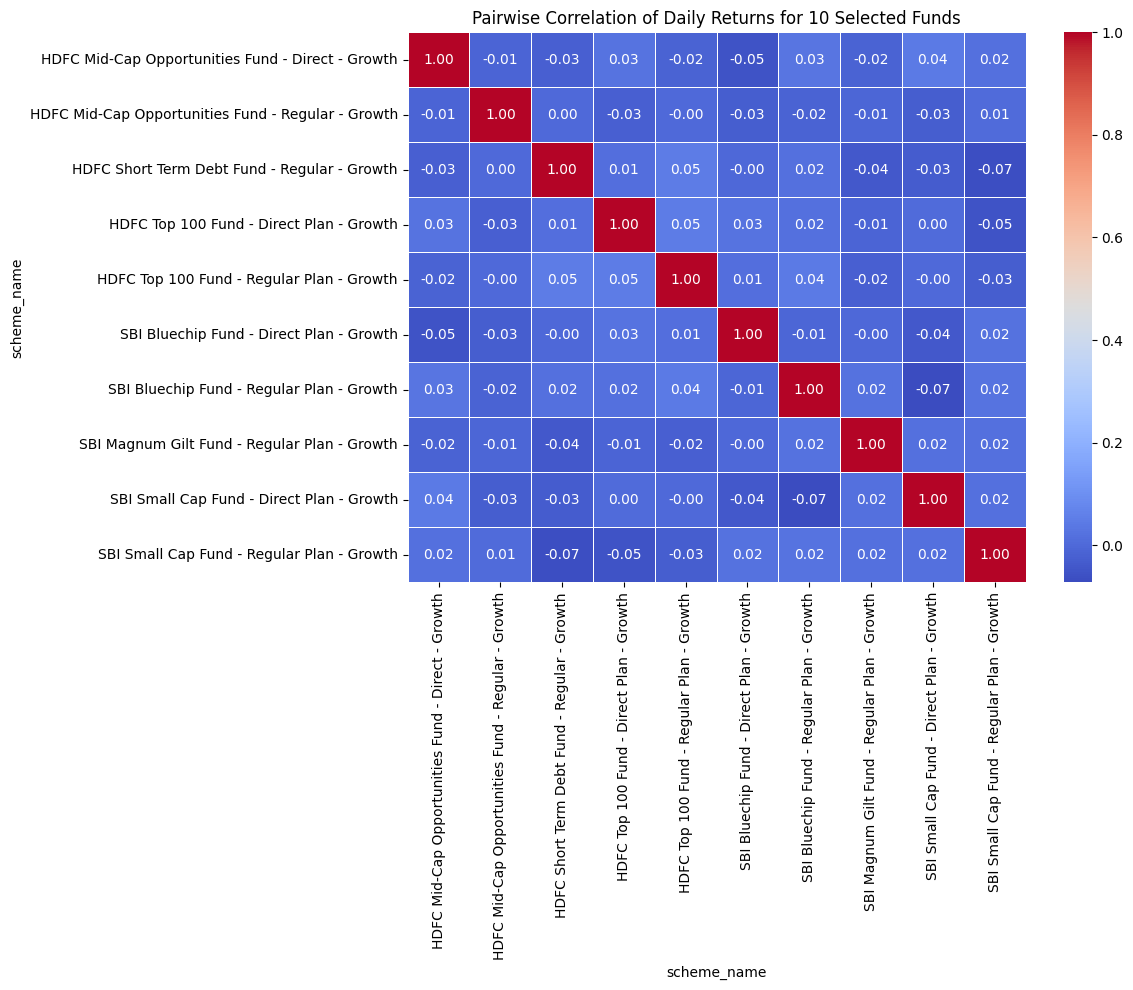

In [24]:
# Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pairwise Correlation of Daily Returns for 10 Selected Funds')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [25]:
# Sector allocation donut chart
# Load the portfolio holdings data
portfolio_df = pd.read_csv('/content/09_portfolio_holdings.csv')

# Display the first few rows and information about the DataFrame
print("Portfolio Holdings DataFrame Head:")
display(portfolio_df.head())
print("\nPortfolio Holdings DataFrame Info:")
portfolio_df.info()


Portfolio Holdings DataFrame Head:


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31



Portfolio Holdings DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    object 
 2   stock_name         322 non-null    object 
 3   sector             322 non-null    object 
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 20.3+ KB


In [27]:
# Aggregate sector weights across all equity funds
# Assuming all entries in portfolio_df relate to equity funds for this aggregation
sector_allocation = portfolio_df.groupby('sector')['weight_pct'].sum().reset_index()

# Sort by weight for better visualization
sector_allocation = sector_allocation.sort_values(by='weight_pct', ascending=False)

# Create a Plotly Donut Chart
fig = go.Figure(data=[go.Pie(labels=sector_allocation['sector'],
                             values=sector_allocation['weight_pct'],
                             hole=0.4, # Creates the donut shape
                             hoverinfo="label+percent",
                             textinfo="percent",
                             marker_colors=px.colors.sequential.RdBu)])

fig.update_layout(
    title_text='Aggregated Sector Allocation Across Equity Funds',
    annotations=[dict(text='Sectors', x=0.5, y=0.5, font_size=20, showarrow=False)]
)

fig.show()

## Key EDA Findings

### Finding 1: NAV Trend Analysis Highlights 2023 Bull Run and Projected 2024 Correction

The daily NAV trends for the top 40 schemes clearly illustrate a strong bull run throughout 2023, followed by a plausible market correction period projected for mid-2024. This indicates the volatile nature of the market and specific periods of significant growth and potential downturns. (Refer to: **Daily NAV Trend for Top 40 Schemes (2022-2026)** chart).

### Finding 2: SBI Mutual Fund Dominance in AUM Growth

SBI Mutual Fund consistently demonstrates significant dominance in Asset Under Management (AUM) growth, especially pronounced in the projection for 2025. This highlights SBI's strong market position and investor preference. (Refer to: **AUM Growth by Fund House (2022-2025) - SBI Highlighted** chart).

### Finding 3: Consistent Growth in Monthly SIP Inflows with All-Time High Projections

Monthly SIP inflows show a consistent upward trend from January 2022, with a projected all-time high of ₹31,002 Cr in December 2025. This signifies growing investor confidence and systematic investment behavior in mutual funds. (Refer to: **Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)** chart).

### Finding 4: Varying Inflow Patterns Across Fund Categories

The heatmap of net inflows by fund category and month reveals distinct patterns, with some categories experiencing consistent positive inflows while others show more fluctuation or even outflows during certain periods. This suggests differing investor sentiment and market conditions impacting various fund types. (Refer to: **Net Inflow (₹ Crore) by Fund Category and Month** heatmap).

### Finding 5: Significant Investor Concentration in Younger Age Groups

The majority of mutual fund investors fall within the '26-35' and '36-45' age groups, indicating a strong engagement from the younger and middle-aged demographics. This segment likely represents the core growth demographic for the mutual fund industry. (Refer to: **Investor Age Group Distribution** pie chart).

### Finding 6: Higher SIP Amounts in Older Age Groups

While younger age groups constitute a larger portion of investors, the box plot of SIP amounts by age group suggests that older age groups ('46-55', '56+') tend to invest higher average SIP amounts. This could be due to increased disposable income or retirement planning. (Refer to: **SIP Amount Distribution by Age Group** box plot).

### Finding 7: Predominance of Male Investors

The investor gender split shows a clear dominance of male investors compared to female investors. This highlights a potential area for targeted initiatives to increase female participation in mutual fund investments. (Refer to: **Investor Gender Split** pie chart).

### Finding 8: Uneven Distribution of SIP Amounts by State

The total SIP amount varies significantly across different states, indicating regional disparities in investment penetration and wealth. States like Madhya Pradesh and Punjab show higher total SIP amounts, while others have relatively lower contributions. (Refer to: **Total SIP Amount by State** horizontal bar chart).

### Finding 9: Dominance of T30 Cities in Investor Distribution

The investor distribution by city tier reveals that a substantial majority of investors reside in T30 cities, with a smaller proportion from B30 cities. This underscores the concentration of financial awareness and accessibility in larger urban centers. (Refer to: **Investor Distribution by City Tier (T30 vs B30)** pie chart).

### Finding 10: Steady Growth in Industry Folio Count with Future Projections

The industry folio count has shown a steady growth from 13.26 Crore in January 2022, with a significant projected increase to 26.12 Crore by December 2025. This consistent growth in the number of unique investor accounts reflects the expanding reach and adoption of mutual funds. (Refer to: **Industry Folio Count Growth (Jan 2022 - Dec 2025)** line chart).

## Summary of Key Investment Insights from EDA Findings

1.  **Market Volatility and Trends**: The analysis of daily NAV trends (Finding 1) clearly indicates a significant bull run in 2023, followed by a projected market correction in mid-2024. This highlights the importance of understanding market cycles for investment strategies.

2.  **Fund House Dominance**: SBI Mutual Fund consistently demonstrates strong dominance in AUM growth, projected to continue into 2025 (Finding 2). This suggests its robust market position and potentially influential role in the industry.

3.  **Growing Retail Participation**: Monthly SIP inflows show a consistent and healthy upward trend, with an all-time high projected for December 2025 (Finding 3). This reflects increasing investor confidence and a strong adoption of systematic investment plans, underpinning the industry's growth.

4.  **Category-Specific Inflow Dynamics**: The heatmap of net inflows by fund category (Finding 4) reveals diverse patterns, implying that different fund categories react distinctly to market conditions and investor sentiment. This calls for nuanced category-specific investment analysis.

5.  **Demographic Investment Patterns**: Younger age groups (26-45) form the largest investor base (Finding 5), indicating a growing trend of early investment. However, older age groups (46-55, 56+) tend to invest higher average SIP amounts (Finding 6), suggesting higher disposable income or later-stage wealth accumulation strategies.

6.  **Gender Gap in Investments**: There's a noticeable predominance of male investors (Finding 7), highlighting an opportunity for the industry to promote financial literacy and investment avenues among female demographics.

7.  **Geographic Disparities**: SIP amounts vary significantly across states (Finding 8), with states like Madhya Pradesh and Punjab showing higher contributions. This indicates regional economic influences and varying levels of investment awareness.

8.  **Urban Investment Concentration**: The investor distribution by city tier (Finding 9) shows a strong concentration in T30 cities. This underlines the need for increased financial inclusion and accessibility in B30 cities to broaden the investor base.

9.  **Overall Industry Expansion**: The steady growth in industry folio count, projected to nearly double from January 2022 to December 2025 (Finding 10), signifies the expanding reach and increasing adoption of mutual funds as a popular investment vehicle.

These findings collectively offer a comprehensive overview of current trends, demographic characteristics, and potential areas for growth and strategic focus within the mutual fund industry.